In [1]:
import mdtraj as md
import numpy as np
import os
import pandas as pd
from contact_map import ContactFrequency
from contact_map import ContactMap, ContactCount, ContactFrequency, ContactDifference, AtomMismatchedContactDifference
from numpy import *
import time
import itertools as it
import statistics as stat
import json

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
start_time = time.time()

In [3]:
n_sim = 10
asn_framenum = 4900000 * n_sim
con_framenum = 4800000 * n_sim
stride = 100 
row_num_contact_matrices = 23
kmax = 30

In [4]:
# Pathways to .csv files
csv_file_pa = '/data/kianseth/contact_maps/pa_contact_matrices_every_100.csv'
csv_file_a = '/data/kianseth/contact_maps/a_contact_matrices_every_100.csv'
csv_file_pc = '/data/kianseth/contact_maps/pc_contact_matrices_every_100.csv'
csv_file_c = '/data/kianseth/contact_maps/c_contact_matrices_every_100.csv'

# Read the .csv files and convert them into dataframes
df_list_pa = pd.read_csv(csv_file_pa, header=None) # 'header=None' converts header into first row of df
df_list_a = pd.read_csv(csv_file_a, header=None)
df_list_pc = pd.read_csv(csv_file_pc, header=None)
df_list_c = pd.read_csv(csv_file_c, header=None)

# Now split the big dataframes into 23x23 dataframes
df_headers_contact_matrices_pa = np.array_split(df_list_pa, int(asn_framenum/stride))
df_headers_contact_matrices_a = np.array_split(df_list_a, int(asn_framenum/stride))
df_headers_contact_matrices_pc = np.array_split(df_list_pc, int(con_framenum/stride))
df_headers_contact_matrices_c = np.array_split(df_list_c, int(con_framenum/stride))


/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [7]:
df_headers_contact_matrices_pa[0].drop(0, axis=1)

,1,2,3,4,5,6,7,8,9,10,...,14,15,16,17,18,19,20,21,22,23
0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
def drop_headers_from_df(list_of_dfs):
    new_dfs = []
    for df in list_of_dfs:
        df1 = df.reset_index()
        df2 = df1.drop(0, axis=0)
        df3 = df2.drop(['index',0], axis=1)
        new_dfs.append(df3)
    return new_dfs

In [25]:
df1 = df_headers_contact_matrices_pa[0].reset_index()
df2 = df1.drop(0, axis=0)
df3 = df2.drop(['index',0], axis=1)

In [11]:
test_drop_h = drop_headers_from_df(df_headers_contact_matrices_pa[0:100])
test_drop_h[5]

,1,2,3,4,5,6,7,8,9,10,...,14,15,16,17,18,19,20,21,22,23
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
%%time
df_contact_matrices_pa = drop_headers_from_df(df_headers_contact_matrices_pa)

CPU times: user 3min 54s, sys: 4.17 s, total: 3min 58s
Wall time: 3min 59s


In [13]:
#df_contact_matrices_pa = drop_headers_from_df(df_headers_contact_matrices_pa)
df_contact_matrices_a = drop_headers_from_df(df_headers_contact_matrices_a)
df_contact_matrices_pc = drop_headers_from_df(df_headers_contact_matrices_pc)
df_contact_matrices_c = drop_headers_from_df(df_headers_contact_matrices_c)

In [14]:
all_contact_matrices = df_contact_matrices_pa + df_contact_matrices_a + df_contact_matrices_pc + df_contact_matrices_c

In [15]:
def dataframes_list_to_arrays(list_of_dfs):
    new_array_list =[]
    for df in list_of_dfs:
        numpy_arrays = df.to_numpy(na_value=0)
        new_array_list.append(numpy_arrays)
    return new_array_list

In [20]:
all_contact_arrays = dataframes_list_to_arrays(all_contact_matrices)

In [23]:
#(23,23) indicates 23 rows, 23 columns...
# Want to make it 1D now, not 2D.
all_contact_arrays_1D = np.array([m.flatten() for m in all_contact_arrays])
print(all_contact_arrays_1D.shape)
print(all_contact_arrays_1D)

(1940000, 529)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


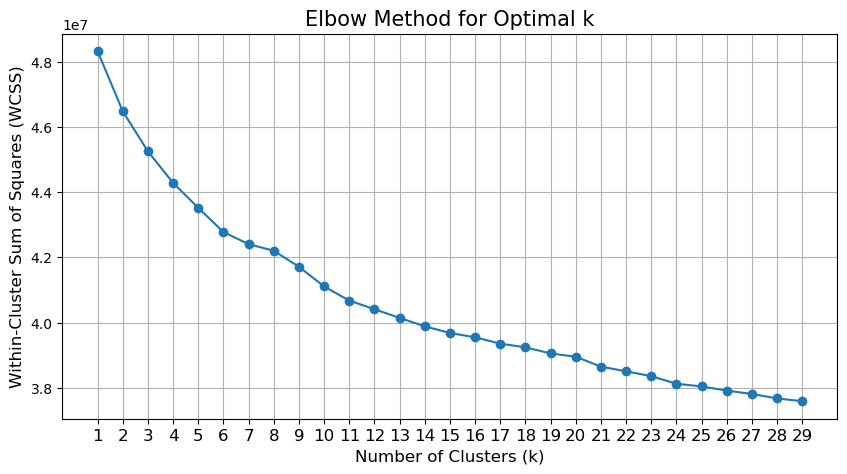

In [24]:
wcss = []
k_values = range(1, kmax) # Test k from 1 up to (number of samples - 1)

for k in k_values:
    # Initialize kmeans model
    # n_init='auto' is recommended in newer scikit-learn versions
    # random_state for reproducibility
    kmeans = KMeans(n_clusters=k, 
                    init='k-means++', 
                    n_init='auto', 
                    random_state=42)

    # Fit the model to your data
    kmeans.fit(all_contact_arrays_1D)

    # Append the WCSS (inertia) to the list
    wcss.append(kmeans.inertia_)

# Plot the WCSS values 
plt.figure(figsize=(10, 5))
plt.plot(k_values, wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k', fontsize=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.xticks(k_values, fontsize=12) # Ensure all k values are shown on the x-axis
plt.grid(True)
plt.show()